# Imports

In [423]:
import numpy as np
import pandas as pd
import glob
import os
import random

import cv2
import tensorflow as tf
import tfimm
import timm
from builtins import range, input
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

import torch
import torch_geometric
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
import torch.nn.functional as F

In [458]:
## Hyperparameters

# PVTAD models
vis_epochs = 20
vis_batch_size = 32

# GNN models
gnn_epochs = 50 # Graph data may require fewer epochs to converge
gnn_batch_size = 64 # Graph data is smaller so we can use a larger batch size for training
hidden_channels = 32
dropout = 0.5
weight_decay = 0.00005
k_neighbors = 10 # Each node will be connected only to its k nearest neighbors
random_state = random.randint(0, 10000)
print(f"Random state: {random_state}")
heads = 4

Random state: 7424


# Data Loading and FC Matrix Computation

In [426]:
# Compute Pearson Correlation Matrix

def compute_fc_matrix(filepath):
    # Each .1D file: rows = timepoints, columns = ROIs
    timeseries = np.loadtxt(filepath)  # shape: (T, n_rois)
    fc_matrix = np.corrcoef(timeseries.T)  # transpose so corrcoef treats ROIs as variables
    return fc_matrix

# Example: process every downloaded file
filepaths = glob.glob('./data/abide_aal_data/Outputs/cpac/filt_global/rois_cc200/*.1D')  # adjust path/pattern to match your download
fc_matrices = {}

for fp in filepaths:
    file_id = os.path.basename(fp).replace('_rois_cc200.1D', '')  # strip suffix to get FILE_ID
    fc_matrices[file_id] = compute_fc_matrix(fp)

print(f"Processed {len(fc_matrices)} subjects")
print(f"Matrix shape: {next(iter(fc_matrices.values())).shape}")  # should be (200, 200) for CC200

c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\bbret\miniconda3\envs\ml-env\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Processed 884 subjects
Matrix shape: (200, 200)


In [427]:
# Count the number of subjects that have 0 standard deviation

nan_counts = {}
for file_id, matrix in fc_matrices.items():
    n_nan = np.isnan(matrix).sum()
    if n_nan > 0:
        nan_counts[file_id] = n_nan

print(f"{len(nan_counts)} of {len(fc_matrices)} subjects have NaNs")
if nan_counts:
    # show the worst few
    worst = sorted(nan_counts.items(), key=lambda x: -x[1])[:5]
    print("Worst offenders:", worst)

35 of 884 subjects have NaNs
Worst offenders: [('Caltech_0051478', 33276), ('Caltech_0051469', 25600), ('SDSU_0050209', 10071), ('SDSU_0050216', 6144), ('Caltech_0051471', 5404)]


In [428]:
# Remove NaN subjects from the dictionary of matrices

fc_matrices_clean = {fid: mat for fid, mat in fc_matrices.items() if not np.isnan(mat).any()}
print(f"Kept {len(fc_matrices_clean)} of {len(fc_matrices)} subjects")

Kept 849 of 884 subjects


# Phenotypic Label Merge

In [429]:
# Merge subject data with phenotypic labels

pheno = pd.read_csv('./data/Phenotypic_V1_0b_preprocessed1.csv')

# Build labels lookup
labels = pheno[['FILE_ID', 'DX_GROUP']].copy()
labels = labels[labels['FILE_ID'] != 'no_filename']

# Merge with your CLEAN matrices
matched_data = []
for file_id, matrix in fc_matrices_clean.items():
    row = labels[labels['FILE_ID'] == file_id]
    if not row.empty:
        dx = row['DX_GROUP'].values[0]
        matched_data.append((file_id, matrix, dx))

print(f"Matched {len(matched_data)} of {len(fc_matrices_clean)} subjects to labels")
print(matched_data)

Matched 849 of 849 subjects to labels
[('Caltech_0051459', array([[ 1.        , -0.1773661 , -0.00602314, ..., -0.28906846,
        -0.34674923,  0.00569531],
       [-0.1773661 ,  1.        ,  0.23651303, ...,  0.17127448,
        -0.06847432, -0.31333132],
       [-0.00602314,  0.23651303,  1.        , ..., -0.07478013,
        -0.01658607, -0.04234176],
       ...,
       [-0.28906846,  0.17127448, -0.07478013, ...,  1.        ,
         0.03017183, -0.22089793],
       [-0.34674923, -0.06847432, -0.01658607, ...,  0.03017183,
         1.        , -0.17733803],
       [ 0.00569531, -0.31333132, -0.04234176, ..., -0.22089793,
        -0.17733803,  1.        ]]), 1), ('Caltech_0051461', array([[ 1.        , -0.23663444, -0.22839338, ...,  0.32799874,
         0.13613338,  0.0465256 ],
       [-0.23663444,  1.        ,  0.46683256, ...,  0.01660224,
        -0.07951879, -0.301523  ],
       [-0.22839338,  0.46683256,  1.        , ..., -0.00145756,
         0.11205156, -0.58666855],
   

In [430]:
import collections
labels_only = [dx for (_, _, dx) in matched_data]
print(collections.Counter(labels_only))

Counter({2: 458, 1: 391})


In [431]:
# Separate matrices by diagnosis group

ASD_matrices = [(fid, mat) for (fid, mat, dx) in matched_data if dx == 1]
TDC_matrices = [(fid, mat) for (fid, mat, dx) in matched_data if dx == 2]

print(f"ASD subjects: {len(ASD_matrices)}")
print(f"TDC subjects: {len(TDC_matrices)}")

ASD subjects: 391
TDC subjects: 458


# Preprocessing and Normalization

##### Vision models

In [432]:
# Build X and y arrays from matched_data
X = np.array([mat for (_, mat, _) in matched_data])  # shape: (849, 200, 200)
y = np.array([dx for (_, _, dx) in matched_data])    # shape: (849,)

# Normalize: map correlation values from [-1, 1] to [0, 1]
X = (X + 1) / 2

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X min: {X.min():.4f}, X max: {X.max():.4f}")  # should be ~0.0 to ~1.0

# Convert ABIDE coding (1=ASD, 2=TDC) to binary (1=ASD, 0=TDC)
y = (y == 1).astype(np.int32)

print(collections.Counter(y))  # should show {0: 458, 1: 391}

X shape: (849, 200, 200)
y shape: (849,)
X min: 0.0204, X max: 1.0000
Counter({0: 458, 1: 391})


##### Graph models

In [433]:
# Build a second, non-rescaled version of the FC matrices for GNN
# (top-k sparsification needs real correlation sign/magnitude, not [0,1]-rescaled values)

X_gnn = np.array([mat for (_, mat, _) in matched_data])  # shape: (849, 200, 200), raw correlations
# no need for a y_graph since the labels are the same as for X and y
print(f"X_gnn shape: {X_gnn.shape}")
print(f"X_gnn min: {X_gnn.min():.4f}, X_gnn max: {X_gnn.max():.4f}")  # should be close to -1.0 to 1.0

X_gnn shape: (849, 200, 200)
X_gnn min: -0.9593, X_gnn max: 1.0000


# Train Val Test Split

##### Vision models

In [434]:
from sklearn.model_selection import train_test_split

# First split: train (70%) vs. temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=91
)

# Second split: val (15%) vs. test (15%) from the temp 30%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=91
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Train labels: {collections.Counter(y_train)}")
print(f"Val labels:   {collections.Counter(y_val)}")
print(f"Test labels:  {collections.Counter(y_test)}")

Train: 594, Val: 127, Test: 128
Train labels: Counter({0: 320, 1: 274})
Val labels:   Counter({0: 69, 1: 58})
Test labels:  Counter({0: 69, 1: 59})


##### Graph models

In [435]:
# Parallel split for the GNN's raw FC matrices — identical partition of subjects,
# since it uses the same y array, same test_size, same random_state as the split above

X_train_gnn, X_temp_gnn, y_train_gnn, y_temp_gnn = train_test_split(
    X_gnn, y, test_size=0.3, stratify=y, random_state=random_state
)

X_val_gnn, X_test_gnn, y_val_gnn, y_test_gnn = train_test_split(
    X_temp_gnn, y_temp_gnn, test_size=0.5, stratify=y_temp_gnn, random_state=random_state
)

print(f"Graph train: {len(X_train_gnn)}, val: {len(X_val_gnn)}, test: {len(X_test_gnn)}")

Graph train: 594, val: 127, test: 128


# Model Definition ----------------

##### Reshape data for vision transformers

In [436]:
import tensorflow as tf
from keras.layers import Input

# Resize and tile X arrays to match pretrained backbone expectations
# Commented out the below 3 lines (Change A)
X_train_model = tf.image.resize(X_train[..., np.newaxis], [224, 224]).numpy()
X_val_model   = tf.image.resize(X_val[..., np.newaxis],   [224, 224]).numpy()
X_test_model  = tf.image.resize(X_test[..., np.newaxis],  [224, 224]).numpy()
# Replaced below 3 with above 3 (Original i think)
# Tile single channel to 3 channels (pretrained models expect RGB-like input)
X_train_model = np.repeat(X_train_model, 3, axis=-1)
X_val_model   = np.repeat(X_val_model,   3, axis=-1)
X_test_model  = np.repeat(X_test_model,  3, axis=-1)

# Input shape variable used by all three models
cnn_inp_y = Input(shape=(224, 224, 3)) # Changed from (224, 224, 3) to (200, 200, 3) (Change A)
inp_y = Input(shape=(224, 224, 3)) # Added for ViT model (Change C)

print(f"X_train_model shape: {X_train_model.shape}")  # should be (594, 224, 224, 3)
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

X_train_model shape: (594, 224, 224, 3)
X_val_model shape:   (127, 224, 224, 3)
X_test_model shape:  (128, 224, 224, 3)


##### Sparsify FC matrices for GNN

In [437]:
# Function definitions
def sparsify_topk(fc_matrix, k=k_neighbors):
    n = fc_matrix.shape[0]
    mask = np.zeros_like(fc_matrix, dtype=bool)

    for i in range(n):
        row = fc_matrix[i].copy()
        row[i] = 0  # exclude self-loop; GCNConv adds these separately
        top_k_idx = np.argsort(-np.abs(row))[:k]
        mask[i, top_k_idx] = True

    # Union symmetrization: keep edge if either direction was selected
    mask = mask | mask.T

    sparsified = np.where(mask, fc_matrix, 0.0)
    return sparsified

def matrix_to_data(dense_fc_matrix, label, k=k_neighbors):
    sparse_fc = sparsify_topk(dense_fc_matrix, k=k)

    # edge_index: 2 x E array of [source, target] pairs for every surviving edge
    src, tgt = np.nonzero(sparse_fc)
    edge_index = torch.tensor(np.array([src, tgt]), dtype=torch.long)

    # edge_attr: correlation value for each surviving edge, matching edge_index order
    #edge_attr = torch.tensor(sparse_fc[src, tgt], dtype=torch.float)
    # Changed above to below
    edge_attr = torch.tensor(np.abs(sparse_fc[src, tgt]), dtype=torch.float)

    # Node features: full dense row per node (Option 2 — not sparsified)
    x = torch.tensor(dense_fc_matrix, dtype=torch.float)

    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [385]:
# Making the datasets
train_dataset_gnn = [matrix_to_data(X_train_gnn[i], y_train_gnn[i]) for i in range(len(X_train_gnn))]
val_dataset_gnn   = [matrix_to_data(X_val_gnn[i],   y_val_gnn[i])   for i in range(len(X_val_gnn))]
test_dataset_gnn  = [matrix_to_data(X_test_gnn[i],  y_test_gnn[i])  for i in range(len(X_test_gnn))]

print(f"Train graphs: {len(train_dataset_gnn)}, Val: {len(val_dataset_gnn)}, Test: {len(test_dataset_gnn)}")
print(train_dataset_gnn[0])  # sanity check — should show x=[200, 200], edge_index=[2, E], y=[1]

Train graphs: 594, Val: 127, Test: 128
Data(x=[200, 200], edge_index=[2, 2718], edge_attr=[2718], y=[1])


##### Vision model definitions

**CNN (ResNet)**

In [386]:
base_model_cnn = tfimm.create_model("resnet18", pretrained="timm", nb_classes=0)

for layer_cnn in base_model_cnn.layers:
    layer_cnn.trainable = False # Changed from False to True
out_cnn = base_model_cnn(inp_y)

out_cnn = Dense(64, activation='relu')(out_cnn)
out_cnn = Dropout(0.5)(out_cnn)
output = Dense(2, activation='softmax')(out_cnn)

model_cnn = Model(inputs=[inp_y], outputs=output)
model_cnn.summary()

All PyTorch model weights were used when initializing ResNet.
All the weights of ResNet were initialized from the PyTorch model.



Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet18 (ResNet)           (None, 512)               11186112  
                                                                 
 dense_4 (Dense)             (None, 64)                32832     
                                                                 
 dropout_171 (Dropout)       (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 2)                 130       
                                                                 
Total params: 11219074 (42.80 MB)
Trainable params: 32962 (128.76 KB)
Non-trainable params: 11186112 (42.67 MB)
_________________________________________________________________


In [387]:
print("model_cnn.output_shape: ", model_cnn.output_shape)

print("y_train.shape: ", y_train.shape)
print("y_val.shape: ", y_val.shape)

print("y_train[:5]: ", y_train[:5])

model_cnn.output_shape:  (None, 2)
y_train.shape:  (594,)
y_val.shape:  (127,)
y_train[:5]:  [0 0 1 1 1]


**ViT**

In [388]:
base_model_vit = tfimm.create_model("vit_tiny_patch16_224", pretrained="timm", nb_classes=0)

for layer_vit in base_model_vit.layers:
    layer_vit.trainable = False # Changed from False to True
out_vit = base_model_vit(inp_y)
out_vit = Flatten()(out_vit)

output = Dense(2, activation='softmax')(out_vit)
model_vit = Model(inputs=[inp_y], outputs=output)
model_vit.summary()

All PyTorch model weights were used when initializing ViT.
All the weights of ViT were initialized from the PyTorch model.



Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vit_tiny_patch16_224 (ViT)  (None, 192)               5524416   
                                                                 
 flatten_6 (Flatten)         (None, 192)               0         
                                                                 
 dense_6 (Dense)             (None, 2)                 386       
                                                                 
Total params: 5524802 (21.08 MB)
Trainable params: 38402 (150.01 KB)
Non-trainable params: 5486400 (20.93 MB)
_________________________________________________________________


**Pyramid ViT**

In [389]:
base_model_pvt = tfimm.create_model("pvt_tiny", pretrained="timm", nb_classes=0)

for layer_pvt in base_model_pvt.layers:
    layer_pvt.trainable = False # Changed from False to True
out_pvt = base_model_pvt(inp_y)
out_pvt = Flatten()(out_pvt)

output = Dense(2, activation='softmax')(out_pvt)
model_pvt = Model(inputs=[inp_y], outputs=output)
model_pvt.summary()

All PyTorch model weights were used when initializing PyramidVisionTransformer.
All the weights of PyramidVisionTransformer were initialized from the PyTorch model.



Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 pvt_tiny (PyramidVisionTra  (None, 512)               12716288  
 nsformer)                                                       
                                                                 
 flatten_7 (Flatten)         (None, 512)               0         
                                                                 
 dense_7 (Dense)             (None, 2)                 1026      
                                                                 
Total params: 12717314 (48.51 MB)
Trainable params: 390914 (1.49 MB)
Non-trainable params: 12326400 (47.02 MB)
_________________________________________________________________


#### GNN model definition

##### GCN

In [438]:
class GCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, dropout):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        self.lin1 = torch.nn.Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = torch.nn.Linear(hidden_channels // 2, 2)

        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr, batch):
        # Layer 1: message passing + activation
        x = self.conv1(x, edge_index, edge_weight=edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2: message passing + activation
        x = self.conv2(x, edge_index, edge_weight=edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Collapse each graph's 200 node embeddings into one graph-level vector
        x = global_mean_pool(x, batch)

        # Classifier head
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x  # raw logits — softmax handled by the loss function, not here

In [439]:
## Initialize GCN model

num_node_features = train_dataset_gnn[0].num_node_features  # 200 for CC200

model_gcn = GCN(num_node_features=num_node_features, hidden_channels=hidden_channels, dropout=dropout)
print(model_gcn)

GCN(
  (conv1): GCNConv(200, 32)
  (conv2): GCNConv(32, 32)
  (lin1): Linear(in_features=32, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=2, bias=True)
)


In [440]:
# Determine which device to use
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model_gcn.to(device)
print(f"Using device: {device}")

Using device: cpu


##### GAT

In [441]:
class GAT(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, dropout, heads):
        super().__init__()
        self.conv1 = GATConv(num_node_features, hidden_channels, dropout=dropout, heads=heads)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, dropout=dropout, heads=heads, concat=False)  # Set concat=False for the second layer to reduce dimensionality

        # conv2's concat=False guarantees the incoming dimension is exactly hidden_channels (32), so this can be a literal copy-paste from the GCN class rather than needing any GAT-specific adjustment.
        self.lin1 = torch.nn.Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = torch.nn.Linear(hidden_channels // 2, 2)

        self.dropout = dropout

    def forward(self, x, edge_index, batch): # removed edge_attr for simplicity
        # Layer 1: message passing + activation
        x = self.conv1(x, edge_index) # removed edge_weight=edge_attr for simplicity
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2: message passing + activation
        x = self.conv2(x, edge_index) # removed edge_weight=edge_attr for simplicity
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Collapse each graph's 200 node embeddings into one graph-level vector
        x = global_mean_pool(x, batch)

        # Classifier head
        x = self.lin1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)

        return x  # raw logits — softmax handled by the loss function, not here

In [442]:
# Initialize GAT model

num_node_features = train_dataset_gnn[0].num_node_features  # 200 for CC200

model_gat = GAT(num_node_features=num_node_features, hidden_channels=hidden_channels, dropout=dropout, heads=heads).to(device)
print(model_gat)

GAT(
  (conv1): GATConv(200, 32, heads=4)
  (conv2): GATConv(128, 32, heads=4)
  (lin1): Linear(in_features=32, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=2, bias=True)
)


# Training ------------

#### Vision models

In [403]:
opt_model_cnn = Adam(learning_rate=0.001)

model_cnn.compile(optimizer=opt_model_cnn, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("CNN Training:")
history_model_cnn = model_cnn.fit(x=X_train_model, y=y_train, epochs=vis_epochs, batch_size=vis_batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

CNN Training:
Epoch 1/20


KeyboardInterrupt: 

In [ ]:
opt_model_vit = Adam(learning_rate=0.001)

model_vit.compile(optimizer=opt_model_vit, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Standard ViT Training:")
history_model_vit = model_vit.fit(x=X_train_model, y=y_train, epochs=vis_epochs, batch_size=vis_batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

Standard ViT Training:
Epoch 1/20
19/19 [==============================] - 28s 1s/step - loss: 0.9193 - accuracy: 0.5000 - val_loss: 0.8294 - val_accuracy: 0.5276
Epoch 2/20
19/19 [==============================] - 19s 1s/step - loss: 0.6685 - accuracy: 0.5909 - val_loss: 0.7480 - val_accuracy: 0.5354
Epoch 3/20
19/19 [==============================] - 20s 1s/step - loss: 0.5853 - accuracy: 0.6835 - val_loss: 0.7350 - val_accuracy: 0.5354
Epoch 4/20
19/19 [==============================] - 20s 1s/step - loss: 0.5313 - accuracy: 0.7306 - val_loss: 0.7416 - val_accuracy: 0.5354
Epoch 5/20
19/19 [==============================] - 20s 1s/step - loss: 0.4675 - accuracy: 0.7879 - val_loss: 0.7441 - val_accuracy: 0.5039
Epoch 6/20
19/19 [==============================] - 20s 1s/step - loss: 0.4082 - accuracy: 0.8603 - val_loss: 0.7461 - val_accuracy: 0.5197
Epoch 7/20
19/19 [==============================] - 19s 975ms/step - loss: 0.3501 - accuracy: 0.8956 - val_loss: 0.7642 - val_accuracy: 0

In [ ]:
opt_model_pvt = Adam(learning_rate=0.001)

model_pvt.compile(optimizer=opt_model_pvt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Pyramid ViT Training:")
history_model_pvt = model_pvt.fit(x=X_train_model, y=y_train, epochs=vis_epochs, batch_size=vis_batch_size, shuffle=True, 
                       validation_data=(X_val_model, y_val))

Pyramid ViT Training:
Epoch 1/20
19/19 [==============================] - 50s 2s/step - loss: 0.7373 - accuracy: 0.5320 - val_loss: 0.6832 - val_accuracy: 0.5748
Epoch 2/20
19/19 [==============================] - 40s 2s/step - loss: 0.6085 - accuracy: 0.7357 - val_loss: 0.6469 - val_accuracy: 0.6535
Epoch 3/20
19/19 [==============================] - 40s 2s/step - loss: 0.4918 - accuracy: 0.8013 - val_loss: 0.6856 - val_accuracy: 0.6142
Epoch 4/20
19/19 [==============================] - 40s 2s/step - loss: 0.3076 - accuracy: 0.9024 - val_loss: 0.8394 - val_accuracy: 0.6220
Epoch 5/20
19/19 [==============================] - 40s 2s/step - loss: 0.1406 - accuracy: 0.9714 - val_loss: 1.0399 - val_accuracy: 0.5827
Epoch 6/20
19/19 [==============================] - 40s 2s/step - loss: 0.0609 - accuracy: 0.9848 - val_loss: 1.1393 - val_accuracy: 0.6142
Epoch 7/20
19/19 [==============================] - 42s 2s/step - loss: 0.0166 - accuracy: 1.0000 - val_loss: 1.2953 - val_accuracy: 0.590

#### GNN model

In [443]:
# Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
gat_optimizer = torch.optim.Adam(model_gat.parameters(), lr=0.001, weight_decay=weight_decay)
#how does adam optimizer work? it is an optimization algorithm that computes adaptive learning rates for each parameter. it combines the advantages of two other extensions of stochastic gradient descent, namely AdaGrad and RMSProp. it keeps track of an exponentially decaying average of past gradients and squared gradients, and uses these to update the parameters.
# do i need a gat_optimizer separately?
loss_function = torch.nn.CrossEntropyLoss() #what is cross entropy loss? it is a loss function that measures the difference between the predicted probability distribution and the true distribution. it is commonly used for classification problems.

In [444]:
# Define dataloaders

train_loader = DataLoader(train_dataset_gnn, batch_size=gnn_batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset_gnn,   batch_size=gnn_batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset_gnn,  batch_size=gnn_batch_size, shuffle=False)

##### GCN

In [395]:
# Define training loop
def train_one_epoch():
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = loss_function(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_loader.dataset)

def evaluate(loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = loss_function(out, batch.y)
            total_loss += loss.item() * batch.num_graphs
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

In [396]:
# Define early stopping parameters
best_val_loss = float('inf')
best_model_state = None
patience = 10
epochs_without_improvement = 0

# Run training loop

# Define a history dictionary to store loss and accuracy for each epoch
history_model_gnn = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(gnn_epochs):
    train_loss = train_one_epoch()
    train_loss_eval, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)

    history_model_gnn['loss'].append(train_loss_eval)
    history_model_gnn['val_loss'].append(val_loss)
    history_model_gnn['accuracy'].append(train_acc)
    history_model_gnn['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    # Check if validation loss has improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Stop training if no improvement for a certain number of epochs
    if epochs_without_improvement >= patience:
        print("Early stopping triggered")
        break
model.load_state_dict(best_model_state)  # restore best checkpoint before eval/test

Epoch 001 | train_loss: 0.6926 | val_loss: 0.6900 | val_acc: 0.5433
Epoch 002 | train_loss: 0.6912 | val_loss: 0.6891 | val_acc: 0.5433
Epoch 003 | train_loss: 0.6899 | val_loss: 0.6885 | val_acc: 0.5433
Epoch 004 | train_loss: 0.6866 | val_loss: 0.6878 | val_acc: 0.5433
Epoch 005 | train_loss: 0.6876 | val_loss: 0.6874 | val_acc: 0.5433
Epoch 006 | train_loss: 0.6893 | val_loss: 0.6871 | val_acc: 0.5433
Epoch 007 | train_loss: 0.6868 | val_loss: 0.6867 | val_acc: 0.5433
Epoch 008 | train_loss: 0.6889 | val_loss: 0.6866 | val_acc: 0.5433
Epoch 009 | train_loss: 0.6858 | val_loss: 0.6853 | val_acc: 0.5433
Epoch 010 | train_loss: 0.6827 | val_loss: 0.6843 | val_acc: 0.5433
Epoch 011 | train_loss: 0.6821 | val_loss: 0.6830 | val_acc: 0.5433
Epoch 012 | train_loss: 0.6795 | val_loss: 0.6815 | val_acc: 0.5433
Epoch 013 | train_loss: 0.6780 | val_loss: 0.6795 | val_acc: 0.5433
Epoch 014 | train_loss: 0.6673 | val_loss: 0.6765 | val_acc: 0.5354
Epoch 015 | train_loss: 0.6675 | val_loss: 0.672

<All keys matched successfully>

##### GAT Training

In [445]:
# Define training loop
def gat_train_one_epoch():
    model_gat.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        gat_optimizer.zero_grad()
        out = model_gat(batch.x, batch.edge_index, batch.batch) #why doesnt gat use edge_attr? i think it does, but the code is written to not use it. maybe because gat doesnt need edge weights?
        loss = loss_function(out, batch.y)
        loss.backward()
        gat_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_loader.dataset)

def gat_evaluate(loader):
    model_gat.eval()
    total_loss, correct = 0, 0
    with torch.no_grad(): # what is no_grad? it means dont compute gradients, which is faster and uses less memory. we dont need gradients for evaluation
        for batch in loader: # what is batch? it is a batch of graphs, each graph has its own nodes and edges. the batch is a list of graphs, each graph is a Data object. the Data object has x (node features), edge_index (edge list), edge_attr (edge features), y (label), and batch (graph index for each node).
            batch = batch.to(device)
            out = model_gat(batch.x, batch.edge_index, batch.batch)
            loss = loss_function(out, batch.y)
            total_loss += loss.item() * batch.num_graphs
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy

In [446]:
# Define early stopping parameters

best_val_loss = float('inf')
best_model_state = None
patience = 10
epochs_without_improvement = 0

history_model_gat = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

# Training loop for GAT
for epoch in range(gnn_epochs):
    train_loss = gat_train_one_epoch()
    train_loss_eval, train_acc = gat_evaluate(train_loader)
    val_loss, val_acc = gat_evaluate(val_loader)

    history_model_gat['loss'].append(train_loss_eval)
    history_model_gat['val_loss'].append(val_loss)
    history_model_gat['accuracy'].append(train_acc)
    history_model_gat['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_gat.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model_gat.load_state_dict(best_model_state)  # restore best checkpoint before eval/test

Epoch 001 | train_loss: 0.6967 | val_loss: 0.6918 | val_acc: 0.5276
Epoch 002 | train_loss: 0.6915 | val_loss: 0.6881 | val_acc: 0.5433
Epoch 003 | train_loss: 0.6899 | val_loss: 0.6841 | val_acc: 0.5433
Epoch 004 | train_loss: 0.6838 | val_loss: 0.6746 | val_acc: 0.5748
Epoch 005 | train_loss: 0.6730 | val_loss: 0.6545 | val_acc: 0.6378
Epoch 006 | train_loss: 0.6469 | val_loss: 0.6315 | val_acc: 0.6457
Epoch 007 | train_loss: 0.6143 | val_loss: 0.6100 | val_acc: 0.6614
Epoch 008 | train_loss: 0.5786 | val_loss: 0.6070 | val_acc: 0.6614
Epoch 009 | train_loss: 0.5442 | val_loss: 0.6219 | val_acc: 0.6142
Epoch 010 | train_loss: 0.5402 | val_loss: 0.6186 | val_acc: 0.6457
Epoch 011 | train_loss: 0.5521 | val_loss: 0.6330 | val_acc: 0.7008
Epoch 012 | train_loss: 0.5099 | val_loss: 0.6502 | val_acc: 0.5984
Epoch 013 | train_loss: 0.4696 | val_loss: 0.6122 | val_acc: 0.7087
Epoch 014 | train_loss: 0.4491 | val_loss: 0.6512 | val_acc: 0.6299
Epoch 015 | train_loss: 0.4162 | val_loss: 0.686

<All keys matched successfully>

# Evaluation and Results

#### Vision model results

##### CNN

**Results**

In [ ]:
y_pred_cnn = model_cnn.predict(X_test_model, batch_size=vis_batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_cnn = np.argmax(y_pred_cnn, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_cnn)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_cnn).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (ResNet-18):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 2s 206ms/step
Results for Across Y - (ResNet-18):
tp: 68
tn: 8
fp: 51
fn: 1
Accuracy:  0.59375
Sensitivity:  0.9855072463768116
Specificity:  0.13559322033898305
Precision:  0.5714285714285714
F1 Score: 0.7234042553191489
AUC: 0.5605502333578974


**Plots**

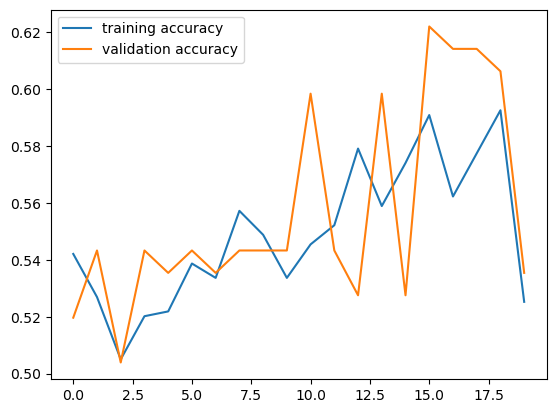

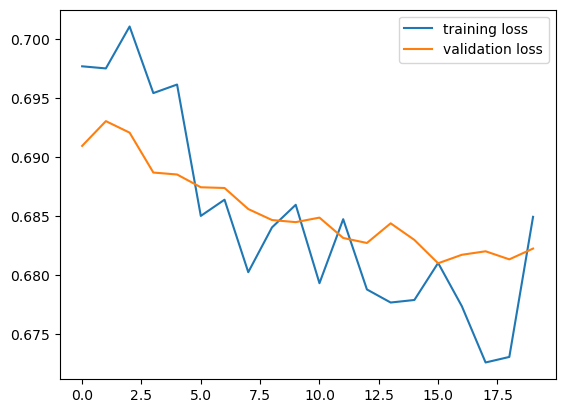

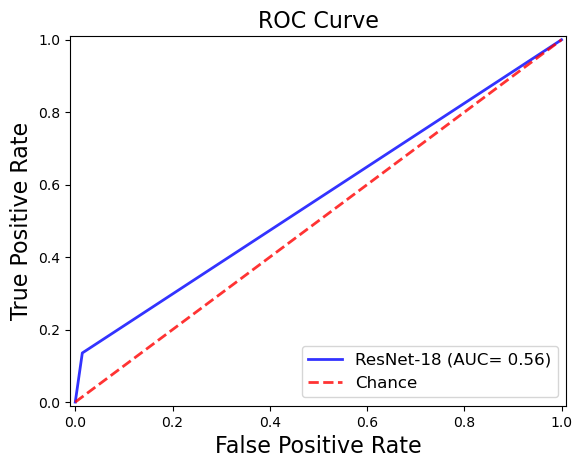

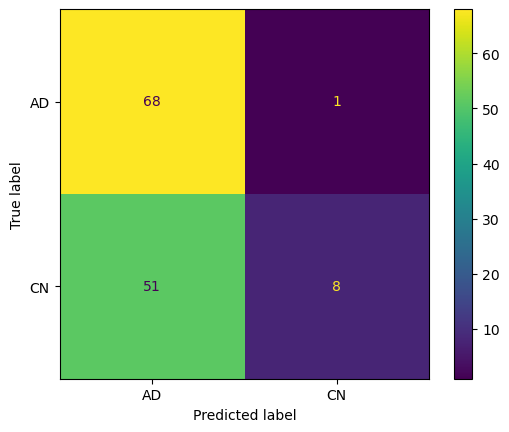

In [ ]:
### Training, validation, and testing plot
plt.plot(history_model_cnn.history["accuracy"], label="training accuracy")
plt.plot(history_model_cnn.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_cnn.history["loss"], label="training loss")
plt.plot(history_model_cnn.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'ResNet-18 (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_cnn)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

##### ViT

**Results**

In [ ]:
y_pred_vit = model_vit.predict(X_test_model, batch_size=vis_batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_vit = np.argmax(y_pred_vit, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_vit)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_vit).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (Standard ViT):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 2s 273ms/step
Results for Across Y - (Standard ViT):
tp: 40
tn: 33
fp: 26
fn: 29
Accuracy:  0.5703125
Sensitivity:  0.5797101449275363
Specificity:  0.559322033898305
Precision:  0.6060606060606061
F1 Score: 0.5925925925925926
AUC: 0.5695160894129205


**Plots**

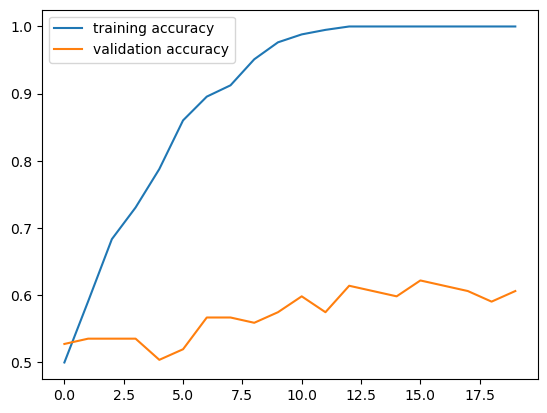

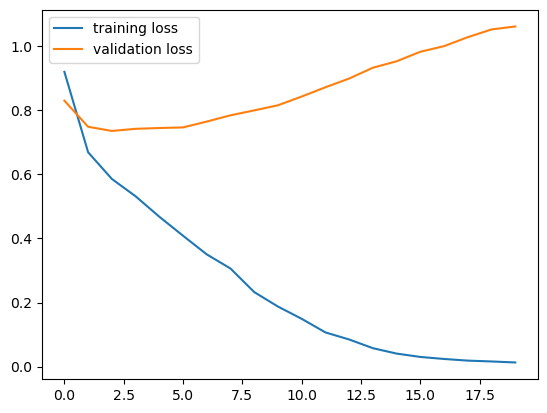

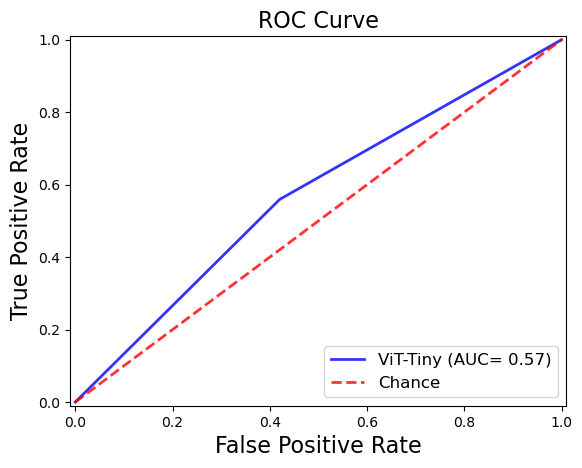

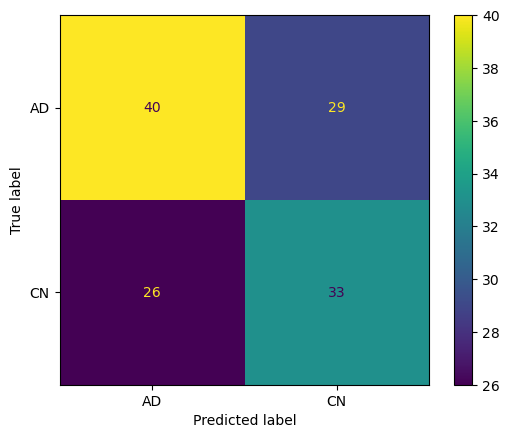

In [ ]:
### Training, validation, and testing plot
plt.plot(history_model_vit.history["accuracy"], label="training accuracy")
plt.plot(history_model_vit.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_vit.history["loss"], label="training loss")
plt.plot(history_model_vit.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'ViT-Tiny (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_vit)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

##### Pyramid ViT

**Results**

In [ ]:
y_pred_pvt = model_pvt.predict(X_test_model, batch_size=vis_batch_size)
y_pred_bin,y_test_bin_y_axis=None,None
y_pred_bin_pvt = np.argmax(y_pred_pvt, axis=1)
y_test_bin_y_axis = y_test
fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_pvt)
roc_auc = auc(fpr, tpr)

tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_pvt).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (Pyramid ViT-Tiny):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)


4/4 [==============================] - 4s 750ms/step
Results for Across Y - (Pyramid ViT-Tiny):
tp: 44
tn: 37
fp: 22
fn: 25
Accuracy:  0.6328125
Sensitivity:  0.6376811594202898
Specificity:  0.6271186440677966
Precision:  0.6666666666666666
F1 Score: 0.6518518518518518
AUC: 0.6323999017440433


**Plots**

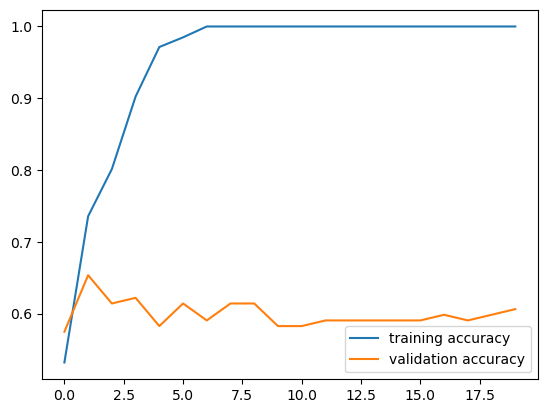

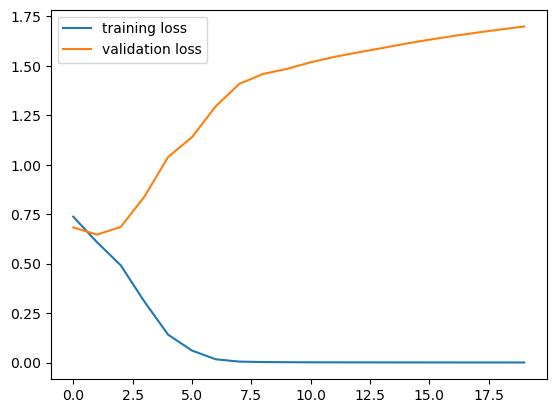

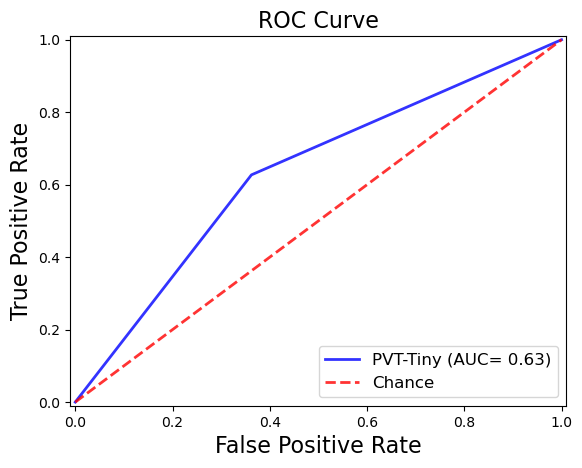

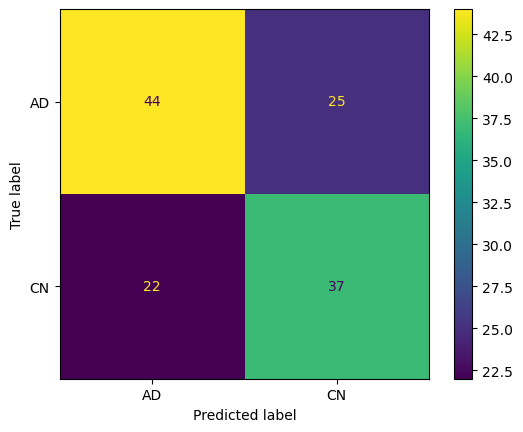

In [ ]:
### Training, validation, and testing plot
plt.plot(history_model_pvt.history["accuracy"], label="training accuracy")
plt.plot(history_model_pvt.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.show()

plt.plot(history_model_pvt.history["loss"], label="training loss")
plt.plot(history_model_pvt.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

### ROC Curve
plt.plot(fpr, tpr, lw=2, color='b', label = 'PVT-Tiny (AUC= %0.2f)' % roc_auc, alpha=.8)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right", prop={'size': 12})
plt.show()

### Confusion Matix Plot
def plot_confusion_matrix():
  classes = ['AD','CN']
#  tick_marks = [0.5,1.5]
  cm = confusion_matrix(y_test_bin_y_axis, y_pred_bin_pvt)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)
  disp.plot()
  plt.show()

plot_confusion_matrix()

#### GNN model results

##### GCN

In [452]:
model.eval()

y_pred_bin_gnn = []
y_test_bin_y_axis = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        preds = out.argmax(dim=1)
        y_pred_bin_gnn.append(preds.cpu())
        y_test_bin_y_axis.append(batch.y.cpu())

y_pred_bin_gnn = torch.cat(y_pred_bin_gnn).numpy()
y_test_bin_y_axis = torch.cat(y_test_bin_y_axis).numpy()

fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_gnn)
roc_auc = auc(fpr, tpr)

# tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_gnn).flatten()
# changes above to below
tn,fp,fn,tp = confusion_matrix(y_test_bin_y_axis,y_pred_bin_gnn).flatten()

sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (GCN):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

Results for Across Y - (GCN):
tp: 0
tn: 69
fp: 0
fn: 59
Accuracy:  0.5390625
Sensitivity:  0.0
Specificity:  1.0
Precision:  nan
F1 Score: nan
AUC: 0.5


C:\Users\bbret\AppData\Local\Temp\ipykernel_41340\410408951.py:26: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp/(tp+fp)


In [466]:
from sklearn.model_selection import StratifiedKFold

k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

fold_results = []

for fold_idx, (train_val_idx, test_idx) in enumerate(skf.split(X_gnn, y)):
    print(f"\n--- Fold {fold_idx+1}/{k_folds} ---")

    # Split this fold's train_val portion further into train/val for early stopping
    X_tv, y_tv = X_gnn[train_val_idx], y[train_val_idx]
    X_te, y_te = X_gnn[test_idx], y[test_idx]

    X_tr, X_va, y_tr, y_va = train_test_split(X_tv, y_tv, test_size=0.15, stratify=y_tv, random_state=random_state)

    fold_train_dataset = [matrix_to_data(X_tr[i], y_tr[i]) for i in range(len(X_tr))]
    fold_val_dataset   = [matrix_to_data(X_va[i], y_va[i]) for i in range(len(X_va))]
    fold_test_dataset  = [matrix_to_data(X_te[i], y_te[i]) for i in range(len(X_te))]

    fold_train_loader = DataLoader(fold_train_dataset, batch_size=gnn_batch_size, shuffle=True)
    fold_val_loader   = DataLoader(fold_val_dataset,   batch_size=gnn_batch_size, shuffle=False)
    fold_test_loader  = DataLoader(fold_test_dataset,  batch_size=gnn_batch_size, shuffle=False)

    # Fresh model per fold
    torch.manual_seed(random_state)
    model = GCN(num_node_features=num_node_features, hidden_channels=32, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.00005)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_state = None
    patience = 10
    epochs_without_improvement = 0

    for epoch in range(gnn_epochs):
        model.train()
        for batch in fold_train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(fold_val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_model_state)

    # Evaluate this fold's held-out test portion
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in fold_test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds.append(out.argmax(dim=1).cpu())
            trues.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    fold_acc = (preds == trues).mean()
    fold_auc = auc(*roc_curve(trues, preds)[:2])

    print(f"Fold {fold_idx+1}: acc={fold_acc:.4f}, auc={fold_auc:.4f}")
    fold_results.append({'fold': fold_idx+1, 'accuracy': fold_acc, 'auc': fold_auc})

import numpy as np
accs = [r['accuracy'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]
print(f"\nMean accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


--- Fold 1/5 ---
Fold 1: acc=0.5824, auc=0.5531

--- Fold 2/5 ---
Fold 2: acc=0.5412, auc=0.5166

--- Fold 3/5 ---
Fold 3: acc=0.5941, auc=0.5665

--- Fold 4/5 ---
Fold 4: acc=0.6176, auc=0.6097

--- Fold 5/5 ---
Fold 5: acc=0.5917, auc=0.5888

Mean accuracy: 0.5854 ± 0.0250
Mean AUC: 0.5669 ± 0.0317


##### GAT

In [450]:
model_gat.eval()

y_pred_bin_gnn = []
y_test_bin_y_axis = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model_gat(batch.x, batch.edge_index, batch.batch)
        preds = out.argmax(dim=1)
        y_pred_bin_gnn.append(preds.cpu())
        y_test_bin_y_axis.append(batch.y.cpu())

y_pred_bin_gnn = torch.cat(y_pred_bin_gnn).numpy()
y_test_bin_y_axis = torch.cat(y_test_bin_y_axis).numpy()

fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_gnn)
roc_auc = auc(fpr, tpr)

tn,fp,fn,tp = confusion_matrix(y_test_bin_y_axis,y_pred_bin_gnn).flatten()
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (GAT):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

Results for Across Y - (GAT):
tp: 28
tn: 46
fp: 23
fn: 31
Accuracy:  0.578125
Sensitivity:  0.4745762711864407
Specificity:  0.6666666666666666
Precision:  0.5490196078431373
F1 Score: 0.5090909090909091
AUC: 0.5706214689265537


In [465]:
from sklearn.model_selection import StratifiedKFold
# what is k-fold cross-validation? it is a technique for assessing how the results of a statistical analysis will generalize to an independent dataset. it is mainly used in settings where the goal is prediction, and one wants to estimate how accurately a predictive model will perform in practice. the data set is partitioned into k equal sized subsamples. of the k subsamples, a single subsample is retained as the validation data for testing the model, and the remaining k − 1 subsamples are used as training data. the cross-validation process is then repeated k times (the folds), with each of the k subsamples used exactly once as the validation data. the k results from the folds can then be averaged (or otherwise combined) to produce a single estimation.
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

fold_results = []

for fold_idx, (train_val_idx, test_idx) in enumerate(skf.split(X_gnn, y)):
    print(f"\n--- Fold {fold_idx+1}/{k_folds} ---")

    # Split this fold's train_val portion further into train/val for early stopping
    X_tv, y_tv = X_gnn[train_val_idx], y[train_val_idx]
    X_te, y_te = X_gnn[test_idx], y[test_idx]

    X_tr, X_va, y_tr, y_va = train_test_split(X_tv, y_tv, test_size=0.15, stratify=y_tv, random_state=random_state)

    fold_train_dataset = [matrix_to_data(X_tr[i], y_tr[i]) for i in range(len(X_tr))]
    fold_val_dataset   = [matrix_to_data(X_va[i], y_va[i]) for i in range(len(X_va))]
    fold_test_dataset  = [matrix_to_data(X_te[i], y_te[i]) for i in range(len(X_te))]

    fold_train_loader = DataLoader(fold_train_dataset, batch_size=gnn_batch_size, shuffle=True)
    fold_val_loader   = DataLoader(fold_val_dataset,   batch_size=gnn_batch_size, shuffle=False)
    fold_test_loader  = DataLoader(fold_test_dataset,  batch_size=gnn_batch_size, shuffle=False)

    # Fresh model per fold
    torch.manual_seed(random_state)
    model = GAT(num_node_features=num_node_features, hidden_channels=32, dropout=0.5, heads=heads).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.00005)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_state = None
    patience = 10
    epochs_without_improvement = 0

    for epoch in range(gnn_epochs):
        model.train()
        for batch in fold_train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = gat_evaluate(fold_val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_model_state)

    # Evaluate this fold's held-out test portion
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in fold_test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            preds.append(out.argmax(dim=1).cpu())
            trues.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    fold_acc = (preds == trues).mean()
    fold_auc = auc(*roc_curve(trues, preds)[:2])

    print(f"Fold {fold_idx+1}: acc={fold_acc:.4f}, auc={fold_auc:.4f}")
    fold_results.append({'fold': fold_idx+1, 'accuracy': fold_acc, 'auc': fold_auc})

import numpy as np
accs = [r['accuracy'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]
print(f"\nMean accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


--- Fold 1/5 ---
Fold 1: acc=0.6588, auc=0.6496

--- Fold 2/5 ---
Fold 2: acc=0.6294, auc=0.6303

--- Fold 3/5 ---
Fold 3: acc=0.6471, auc=0.6183

--- Fold 4/5 ---
Fold 4: acc=0.6059, auc=0.5851

--- Fold 5/5 ---
Fold 5: acc=0.6036, auc=0.5916

Mean accuracy: 0.6289 ± 0.0219
Mean AUC: 0.6150 ± 0.0240


# Ensembling
garbage

In [331]:
def train_one_model(seed, hidden_channels=32, dropout=0.5, weight_decay=0.0005, patience=10):
    torch.manual_seed(seed)
    model = GCN(num_node_features=num_node_features, hidden_channels=hidden_channels, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(gnn_epochs):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_model_state)
    return model

In [332]:
n_ensemble = 10
ensemble_seeds = [19, 21, 84, 16, 63, 58, 7, 55, 91, 33]  # Example seeds for reproducibility

ensemble_models = []
for seed in ensemble_seeds:
    print(f"Training model with seed {seed}...")
    m = train_one_model(seed)
    ensemble_models.append(m)
print("Done training ensemble.")

Training model with seed 19...
Training model with seed 21...
Training model with seed 84...
Training model with seed 16...
Training model with seed 63...
Training model with seed 58...
Training model with seed 7...
Training model with seed 55...
Training model with seed 91...
Training model with seed 33...
Done training ensemble.


In [333]:
for i, m in enumerate(ensemble_models):
    m.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = m(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds.append(out.argmax(dim=1).cpu())
            trues.append(batch.y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    acc = (preds == trues).mean()
    unique, counts = np.unique(preds, return_counts=True)
    print(f"Model {i} (seed {ensemble_seeds[i]}): acc={acc:.4f}, prediction distribution={dict(zip(unique, counts))}")

Model 0 (seed 19): acc=0.5703, prediction distribution={0: 112, 1: 16}
Model 1 (seed 21): acc=0.5391, prediction distribution={0: 128}
Model 2 (seed 84): acc=0.5391, prediction distribution={0: 128}
Model 3 (seed 16): acc=0.5391, prediction distribution={0: 128}
Model 4 (seed 63): acc=0.5391, prediction distribution={0: 128}
Model 5 (seed 58): acc=0.5391, prediction distribution={0: 128}
Model 6 (seed 7): acc=0.5391, prediction distribution={0: 128}
Model 7 (seed 55): acc=0.5547, prediction distribution={0: 126, 1: 2}
Model 8 (seed 91): acc=0.5312, prediction distribution={0: 127, 1: 1}
Model 9 (seed 33): acc=0.5391, prediction distribution={0: 128}


In [334]:
all_probs = []  # will hold each model's predicted probability of class 1, per test subject

for m in ensemble_models:
    m.eval()
    probs = []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = m(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            prob = torch.softmax(out, dim=1)[:, 1]  # probability of class 1 (ASD)
            probs.append(prob.cpu())
    all_probs.append(torch.cat(probs).numpy())

# Get true labels once (same order every time since test_loader isn't shuffled)
y_test_bin_y_axis = []
with torch.no_grad():
    for batch in test_loader:
        y_test_bin_y_axis.append(batch.y.cpu())
y_test_bin_y_axis = torch.cat(y_test_bin_y_axis).numpy()

# Average probabilities across ensemble members, then threshold at 0.5
avg_probs = np.mean(all_probs, axis=0)
y_pred_bin_ensemble = (avg_probs >= 0.5).astype(int)

fpr, tpr, threshold = roc_curve(y_test_bin_y_axis, y_pred_bin_ensemble)
roc_auc = auc(fpr, tpr)

#tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_ensemble).flatten()
#tp,fn,fp,tn = confusion_matrix(y_test_bin_y_axis,y_pred_bin_gnn).flatten()
tn, fp, fn, tp = confusion_matrix(y_test_bin_y_axis, y_pred_bin_ensemble).flatten()

sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Results for Across Y - (GCN Ensemble):')
print('tp:',tp)
print('tn:',tn)
print('fp:',fp)
print('fn:',fn)
print('Accuracy: ', (tp+tn)/len(y_test_bin_y_axis))
print('Sensitivity: ', sensitivity)
print('Specificity: ', specificity)
print('Precision: ', precision)
print('F1 Score:', 2*(precision*sensitivity)/(precision+sensitivity))
print('AUC:', roc_auc)

Results for Across Y - (GCN Ensemble):
tp: 0
tn: 69
fp: 0
fn: 59
Accuracy:  0.5390625
Sensitivity:  0.0
Specificity:  1.0
Precision:  nan
F1 Score: nan
AUC: 0.5


C:\Users\bbret\AppData\Local\Temp\ipykernel_41340\3926012167.py:34: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp/(tp+fp)
